# Activity: Understanding Perceptrons and Their Limitations

# Exercise 1

## Data Generation Task
Generate two classes of 2D data points (1000 samples per class) using multivariate normal distributions.  

Use the following parameters:

- **Class 0**:  
  - Mean = [1.5, 1.5]  
  - Covariance matrix = [[0.5, 0], [0, 0.5]]  
    - Variance of 0.5 along each dimension  
    - No covariance  

- **Class 1**:  
  - Mean = [5, 5]  
  - Covariance matrix = [[0.5, 0], [0, 0.5]]  

These parameters ensure the classes are mostly linearly separable, with minimal overlap due to the distance between means and low variance.  
Plot the data points (using libraries like matplotlib if desired) to visualize the separation, coloring points by class.



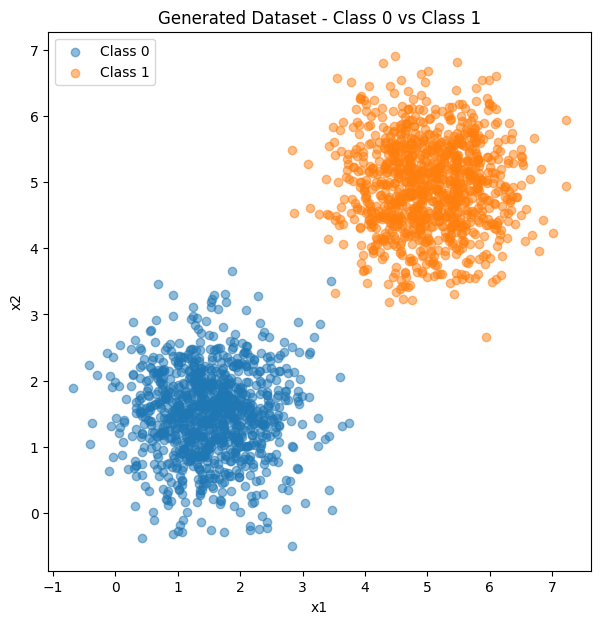

In [34]:
import numpy as np
import matplotlib.pyplot as plt

n_samples = 1000

# Class 0 
mean_class0 = [1.5, 1.5]
cov_class0 = [[0.5, 0], [0, 0.5]]

# Class 1
mean_class1 = [5, 5]
cov_class1 = [[0.5, 0], [0, 0.5]]

# gera os dados
X_class0 = np.random.multivariate_normal(mean_class0, cov_class0, n_samples)
X_class1 = np.random.multivariate_normal(mean_class1, cov_class1, n_samples)

# junta o dataset
X = np.vstack((X_class0, X_class1))
y = np.r_[np.zeros(n_samples), np.ones(n_samples)].astype(int)  # vetores de 1000 zeros e 1000 uns


# Plot
plt.figure(figsize=(7,7))
plt.scatter(X_class0[:,0], X_class0[:,1], alpha=0.5, label="Class 0")
plt.scatter(X_class1[:,0], X_class1[:,1], alpha=0.5, label="Class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Generated Dataset - Class 0 vs Class 1")
plt.show()


## Perceptron Implementation Task:

Implement a single-layer perceptron from scratch to classify the generated data into the two classes. You may use NumPy only for basic linear algebra operations (e.g., matrix multiplication, vector addition/subtraction, dot products). Do not use any pre-built machine learning libraries (e.g., no scikit-learn) or NumPy functions that directly implement perceptron logic.

- Initialize weights (w) as a 2D vector (plus a bias term b). 

- Use the perceptron learning rule: For each misclassified sample (x, y), update  
  $w = w + \eta * y * x $ and $b = b + \eta * y$, where $\eta$ is the learning rate (start with $\eta = 0.01$).  

- Train the model until convergence (no weight updates occur in a full pass over the dataset) or for a maximum of 100 epochs, whichever comes first. If convergence is not achieved by 100 epochs, report the accuracy at that point. Track accuracy after each epoch.

- After training, evaluate accuracy on the full dataset and plot the decision boundary (line defined by $w \cdot x + b = 0$) overlaid on the data points. Additionally, plot the training accuracy over epochs to show convergence progress. Highlight any misclassified points in a separate plot or by different markers in the decision boundary plot.  

Report the final weights, bias, accuracy, and discuss why the data’s separability leads to quick convergence.


Epoch 1: W = [0.03909103 0.04797968], B = 0.0, Accuracy = 0.5005, Erros = 999
Epoch 2: W = [0.03801255 0.02968141], B = -0.03, Accuracy = 0.5060, Erros = 988
Epoch 3: W = [0.04379876 0.04602322], B = -0.05, Accuracy = 0.5145, Erros = 971
Epoch 4: W = [0.04958497 0.06236504], B = -0.07, Accuracy = 0.5185, Erros = 963
Epoch 5: W = [0.04451232 0.06130865], B = -0.09, Accuracy = 0.5425, Erros = 915
Epoch 6: W = [0.02138609 0.06422702], B = -0.10999999999999999, Accuracy = 0.6695, Erros = 661
Epoch 7: W = [0.03402619 0.06863829], B = -0.11999999999999998, Accuracy = 0.6260, Erros = 748
Epoch 8: W = [0.02634797 0.07564548], B = -0.12999999999999998, Accuracy = 0.6680, Erros = 664
Epoch 9: W = [0.01866974 0.08265267], B = -0.13999999999999999, Accuracy = 0.7010, Erros = 598
Epoch 10: W = [0.01099152 0.08965985], B = -0.15, Accuracy = 0.7420, Erros = 516
Epoch 11: W = [0.02363162 0.09407113], B = -0.16, Accuracy = 0.6925, Erros = 615
Epoch 12: W = [0.0159534  0.10107831], B = -0.17, Accuracy =

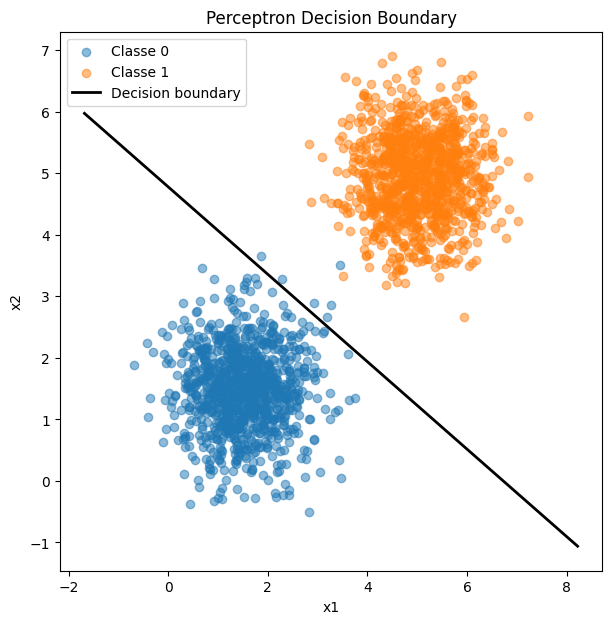

In [35]:
learning = 0.01
epochs = 100
w = np.array([0.0, 0.0])
b = 0.0
erro = 0

updates = 0  # contar quantas vezes houve atualização

def activation(z):
    if z >= 0:
        return 1
    else:
        return 0

def accuracy(X, y, w, b):
    preds = [activation(np.dot(w, x) + b) for x in X]
    return np.mean(preds == y)


for epoch in range(epochs): # vai de 0 a 99
    teve_erro = 0
    for i in range(len(X)):
        analisado = X[i] 
        y_real = y[i]
        z = (w[0] * analisado[0] + w[1] * analisado[1]) + b
        y_previsto = activation(z)
        erro = y_real - y_previsto

        if erro != 0:
            teve_erro = 1
            updates += 1
            w += learning * erro * analisado
            b += learning * erro
    preds = np.array([activation(np.dot(w, x) + b) for x in X])
    acc = np.mean(preds == y)
    erros = np.sum(preds != y)
    print(f"Epoch {epoch+1}: W = {w}, B = {b}, Accuracy = {acc:.4f}, Erros = {erros}")


    if teve_erro == 0:
        print(f"\n Convergiu depois de {epoch+1} epochs com {updates} updates no total.")
        break 


# Plotar depois do treino
# ------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# limites do gráfico
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
x_vals = np.linspace(x_min, x_max, 100)

# equação da reta de decisão: w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b)/w2
y_vals = -(w[0] * x_vals + b) / w[1]

# pontos
plt.figure(figsize=(7,7))
plt.scatter(X[y==0,0], X[y==0,1], alpha=0.5, label="Classe 0")
plt.scatter(X[y==1,0], X[y==1,1], alpha=0.5, label="Classe 1")

# fronteira de decisão
plt.plot(x_vals, y_vals, color="black", linewidth=2, label="Decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Perceptron Decision Boundary")
plt.show()




Após o treinamento, o perceptron convergiu com os seguintes resultados:

* **Pesos finais (w):** \[ $0.0936433$, $0.13178968$ ]
* **Bias final (b):** $-0.6300000000000003$
* **Acurácia:** 99,7%

Durante o treinamento, o perceptron iniciou com acurácia próxima de 50%, praticamente classificando ao acaso. Ao longo das épocas, os pesos e o bias foram sendo ajustados e a acurácia subiu progressivamente, chegando a 99,7% na época 100, com apenas 6 erros no total de 2000 amostras.

O fato de a acurácia não ter atingido 100% pode ser explicado pelas características estatísticas do dataset devido a presença de pontos de sobreposição entre as distribuições das duas classes. Embora os dados tenham sido gerados de forma linearmente separável em média, eles vêm de distribuições normais multivariadas. Esses pontos "ruído" fazem com que não exista uma reta que consiga separar perfeitamente todas as amostras.




# Exercise 2

## Data Generation Task:
Generate two classes of 2D data points (1000 samples per class) using multivariate normal distributions. Use the following parameters:

- **Class 0**:  
  Mean = [3, 3],  
  Covariance matrix = [[1.5, 0], [0, 1.5]] (i.e., higher variance of 1.5 along each dimension).  

- **Class 1**:  
  Mean = [4, 4],  
  Covariance matrix = [[1.5, 0], [0, 1.5]].  

These parameters create partial overlap between classes due to closer means and higher variance, making the data not fully linearly separable. Plot the data points to visualize the overlap, coloring points by class.  



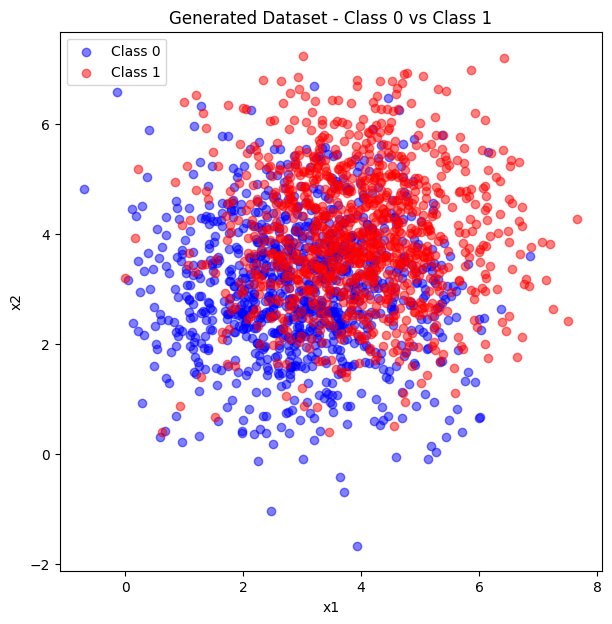

In [49]:
import numpy as np
import matplotlib.pyplot as plt

n_samples = 1000

# Class 0 
mean_class0_2 = [3, 3]
cov_class0_2 = [[1.5, 0], [0, 1.5]]

# Class 1
mean_class1_2 = [4, 4]
cov_class1_2 = [[1.5, 0], [0, 1.5]]

# gera os dados
X_class0_2 = np.random.multivariate_normal(mean_class0_2, cov_class0_2, n_samples)
X_class1_2 = np.random.multivariate_normal(mean_class1_2, cov_class1_2, n_samples)

# junta o dataset
X_2 = np.vstack((X_class0_2, X_class1_2))
y_2 = np.r_[np.zeros(n_samples), np.ones(n_samples)].astype(int)  # vetores de 1000 zeros e 1000 uns


# Plot
plt.figure(figsize=(7,7))
plt.scatter(X_class0_2[:,0], X_class0_2[:,1], color = 'blue', alpha=0.5, label="Class 0")
plt.scatter(X_class1_2[:,0], X_class1_2[:,1], color = 'red', alpha=0.5, label="Class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Generated Dataset - Class 0 vs Class 1")
plt.show()


## Perceptron Implementation Task:
Using the same implementation guidelines as in Exercise 1, train a perceptron on this dataset:

- Follow the same initialization, update rule, and training process. 

- Train the model until convergence (no weight updates occur in a full pass over the dataset) or for a maximum of 100 epochs, whichever comes first. If convergence is not achieved by 100 epochs, report the accuracy at that point and note any oscillation in updates; consider reporting the best accuracy achieved over multiple runs (e.g., average over 5 random initializations). Track accuracy after each epoch.  

- Evaluate accuracy after training and plot the decision boundary overlaid on the data points. Additionally, plot the training accuracy over epochs to show convergence progress (or lack thereof). Highlight any misclassified points in a separate plot or by different markers in the decision boundary plot.  

Report the final weights, bias, accuracy, and discuss how the overlap affects training compared to Exercise 1 (e.g., slower convergence or inability to reach 100% accuracy).

Epoch 1: W = [0.04570227 0.03395184], B = 0.01, Accuracy = 0.5000, Erros = 1000
Epoch 2: W = [0.0421719  0.03914527], B = 0.01, Accuracy = 0.5000, Erros = 1000
Epoch 3: W = [0.01969512 0.04468654], B = 0.01, Accuracy = 0.5000, Erros = 1000
Epoch 4: W = [0.03651198 0.03808257], B = 0.01, Accuracy = 0.5000, Erros = 1000
Epoch 5: W = [0.05332885 0.0314786 ], B = 0.01, Accuracy = 0.5000, Erros = 1000
Epoch 6: W = [0.03079092 0.04171783], B = 0.0, Accuracy = 0.5000, Erros = 1000
Epoch 7: W = [0.04760778 0.03511386], B = 0.0, Accuracy = 0.5000, Erros = 1000
Epoch 8: W = [0.04407741 0.04030729], B = 0.0, Accuracy = 0.5000, Erros = 1000
Epoch 9: W = [0.02160063 0.04584855], B = 0.0, Accuracy = 0.5000, Erros = 1000
Epoch 10: W = [0.03841749 0.03924458], B = 0.0, Accuracy = 0.5000, Erros = 1000
Epoch 11: W = [0.05523436 0.03264061], B = 0.0, Accuracy = 0.5000, Erros = 1000
Epoch 12: W = [0.03269643 0.04287984], B = -0.009999999999999997, Accuracy = 0.5000, Erros = 1000
Epoch 13: W = [0.04951329 

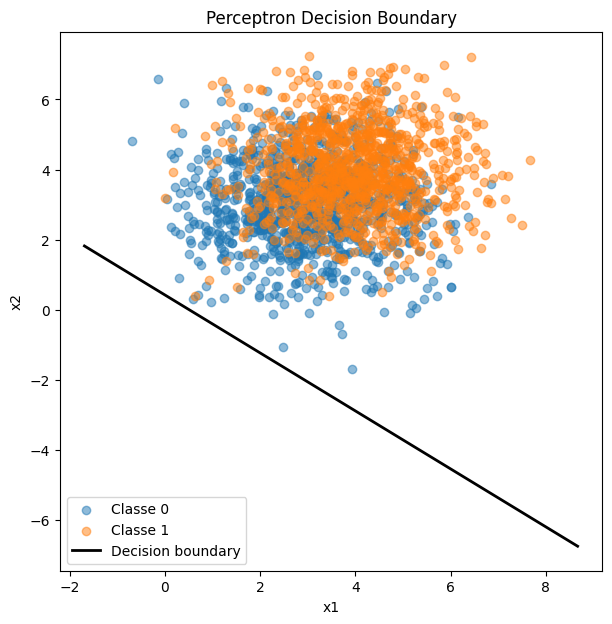

In [50]:
learning = 0.01
epochs = 100
w_2 = np.array([0.0, 0.0])
b_2 = 0.0
erro_2 = 0

updates_2 = 0  # contar quantas vezes houve atualização

accuracies_2 = []

def activation(z):
    if z >= 0:
        return 1
    else:
        return 0


for epoch in range(epochs): # vai de 0 a 99
    teve_erro_2 = 0
    for i in range(len(X_2)):
        analisado_2 = X_2[i] 
        y_real_2 = y_2[i]
        z_2 = (w_2[0] * analisado_2[0] + w_2[1] * analisado_2[1]) + b_2
        y_previsto_2 = activation(z_2)
        erro_2 = y_real_2 - y_previsto_2

        if erro_2 != 0:
            teve_erro_2 = 1
            updates_2 += 1
            w_2 += learning * erro_2 * analisado_2
            b_2 += learning * erro_2
    preds_2 = np.array([activation(np.dot(w_2, x) + b_2) for x in X_2])
    acc_2 = np.mean(preds_2 == y_2)
    accuracies_2.append(acc_2)
    erros_2 = np.sum(preds_2 != y_2)
    print(f"Epoch {epoch+1}: W = {w_2}, B = {b_2}, Accuracy = {acc_2:.4f}, Erros = {erros_2}")


    if teve_erro_2 == 0:
        print(f"\n Convergiu depois de {epoch+1} epochs com {updates_2} updates no total.")
        break 


# Plotar depois do treino
# ------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# limites do gráfico
x_min_2, x_max_2 = X_2[:,0].min() - 1, X_2[:,0].max() + 1
x_vals_2 = np.linspace(x_min_2, x_max_2, 100)

# equação da reta de decisão: w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b)/w2
y_vals_2 = -(w_2[0] * x_vals_2 + b_2) / w_2[1]

# pontos
plt.figure(figsize=(7,7))
plt.scatter(X_2[y_2==0,0], X_2[y_2==0,1], alpha=0.5, label="Classe 0")
plt.scatter(X_2[y_2==1,0], X_2[y_2==1,1], alpha=0.5, label="Classe 1")

# fronteira de decisão
plt.plot(x_vals_2, y_vals_2, color="black", linewidth=2, label="Decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Perceptron Decision Boundary")
plt.show()


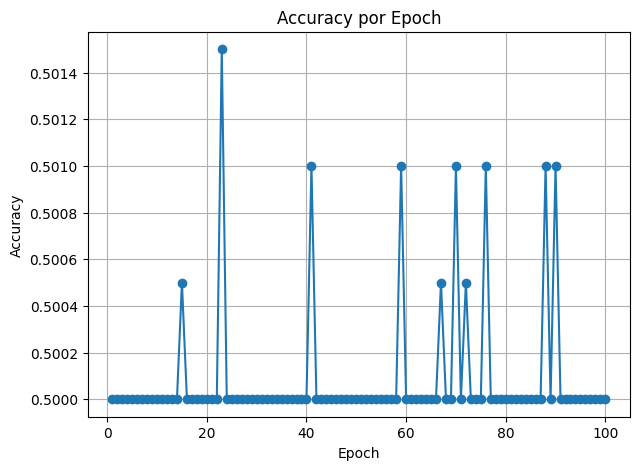

In [51]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(accuracies_2)+1), accuracies_2, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por Epoch")
plt.grid(True)
plt.show()


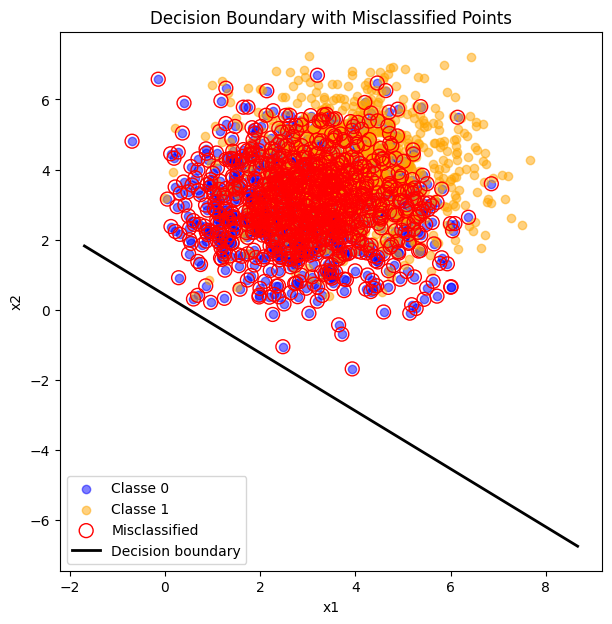

In [52]:
# Identificar erros
misclassified = preds_2 != y_2

plt.figure(figsize=(7,7))
plt.scatter(X_2[y_2==0,0], X_2[y_2==0,1], alpha=0.5, label="Classe 0", color="blue")
plt.scatter(X_2[y_2==1,0], X_2[y_2==1,1], alpha=0.5, label="Classe 1", color="orange")
plt.scatter(X_2[misclassified,0], X_2[misclassified,1], 
            facecolors='none', edgecolors='red', s=100, label="Misclassified")

# Fronteira de decisão
plt.plot(x_vals_2, y_vals_2, color="black", linewidth=2, label="Decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Decision Boundary with Misclassified Points")
plt.show()


## Conclusão

No Exercício 2, o perceptron foi treinado em um dataset com médias mais próximas $[3,3]$ e $[4,4]$ e variância maior (1.5). Como esperado, isso gerou uma forte sobreposição entre as classes, tornando impossível separá-las perfeitamente com uma reta.

O gráfico de acurácia por época mostra que o desempenho do perceptron oscilou em torno de 50%, sem sinais de convergência estável. Diferente do Exercício 1, onde a separação linear clara permitiu atingir quase 100% de acurácia, aqui o perceptron não consegue aprender uma fronteira que divida corretamente todos os pontos.

O gráfico da fronteira de decisão com pontos mal classificados confirma esse resultado: há uma grande quantidade de amostras de ambas as classes no lado “errado” da linha, o que explica a limitação do modelo.